In [1]:
import pandas as pd

print("Pandas imported successfully!")

Pandas imported successfully!


In [4]:
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    "data/raw/uci/processed.cleveland.data",
    header=None,
    names=column_names
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [9]:
print(df['ca'].unique())
print(df['thal'].unique())
df['target'].value_counts()


<StringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str
<StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str


target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [17]:
df['ca'] = df['ca'].replace('?', ca_mode)
df['thal'] = df['thal'].replace('?', thal_mode)

print("Unique values in ca:")
print(df['ca'].unique())

print("\nUnique values in thal:")
print(df['thal'].unique())

df['ca'] = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])

Unique values in ca:
<StringArray>
['0.0', '3.0', '2.0', '1.0']
Length: 4, dtype: str

Unique values in thal:
<StringArray>
['6.0', '3.0', '7.0']
Length: 3, dtype: str


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [19]:
df['ca'] = df['ca'].replace('?', ca_mode)
df['thal'] = df['thal'].replace('?', thal_mode)

In [21]:
print(df['target'].value_counts())

df['target_binary'] = (df['target'] > 0).astype(int)

print(df['target_binary'].value_counts())

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
target_binary
0    164
1    139
Name: count, dtype: int64


Minimum age: 29.0
Maximum age: 77.0
Average age: 54.43894389438944
Median age: 56.0


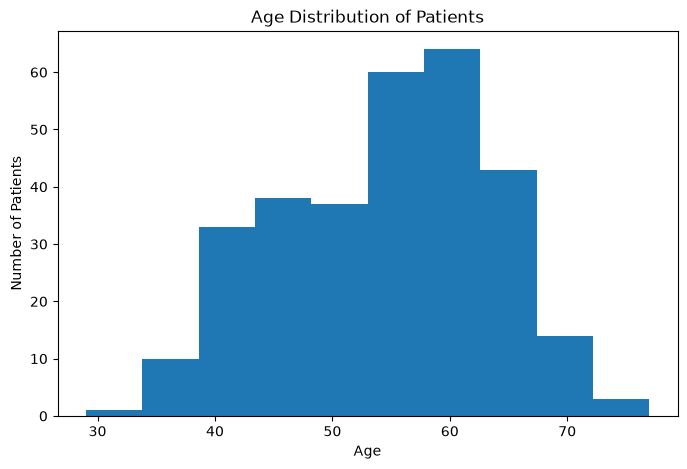

Average age - No heart disease: 52.58536585365854
Average age - Heart disease: 56.62589928057554
Unique values in sex:
[1. 0.]

Value counts:
sex
1.0    206
0.0     97
Name: count, dtype: int64
Unique values in sex:
[1. 0.]
Sex distribution:
sex
1.0    206
0.0     97
Name: count, dtype: int64


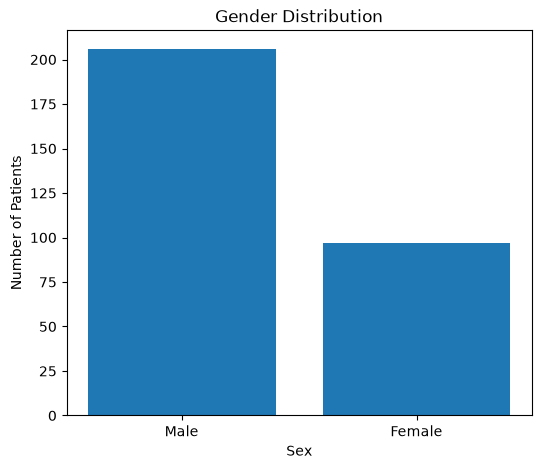

In [28]:
print("Minimum age:", df['age'].min())
print("Maximum age:", df['age'].max())
print("Average age:", df['age'].mean())
print("Median age:", df['age'].median())

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=10)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

print("Average age - No heart disease:",
      df[df['target_binary'] == 0]['age'].mean())

print("Average age - Heart disease:",
      df[df['target_binary'] == 1]['age'].mean())

print("Unique values in sex:")
print(df['sex'].unique())

print("\nValue counts:")
print(df['sex'].value_counts())
print("Unique values in sex:")
print(df['sex'].unique())
print("Sex distribution:")
print(df['sex'].value_counts())
import matplotlib.pyplot as plt

sex_counts = df['sex'].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(['Male', 'Female'], 
        [sex_counts.get(1.0, 0), sex_counts.get(0.0, 0)])

plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Number of Patients')

plt.show()

Heart disease distribution by sex:
target_binary   0    1
sex                   
0.0            72   25
1.0            92  114
target_binary          0          1
sex                                
0.0            74.226804  25.773196
1.0            44.660194  55.339806


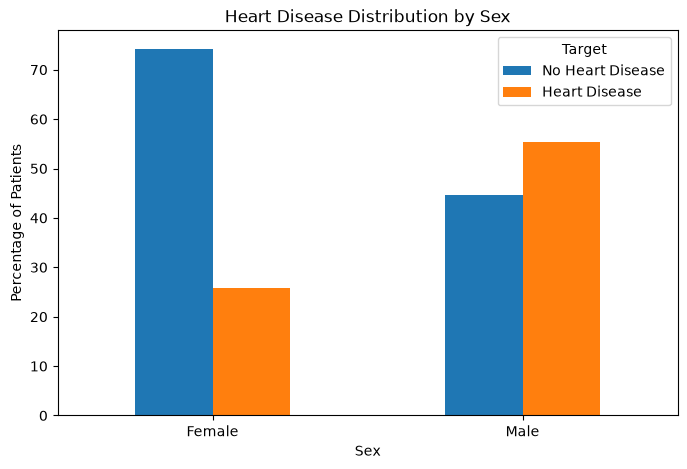

Unique values in cp:
[1. 4. 3. 2.]

Value counts of cp:
cp
1.0     23
2.0     50
3.0     86
4.0    144
Name: count, dtype: int64
Heart disease distribution by chest pain type:
target_binary   0    1
cp                    
1.0            16    7
2.0            41    9
3.0            68   18
4.0            39  105

Percentage distribution:
target_binary          0          1
cp                                 
1.0            69.565217  30.434783
2.0            82.000000  18.000000
3.0            79.069767  20.930233
4.0            27.083333  72.916667


In [34]:
import pandas as pd

print("Heart disease distribution by sex:")
print(pd.crosstab(df['sex'], df['target_binary']))

sex_target_percentage = pd.crosstab(
    df['sex'],
    df['target_binary'],
    normalize='index'
) * 100

print(sex_target_percentage)
sex_target_percentage = pd.crosstab(
    df['sex'],
    df['target_binary'],
    normalize='index'
) * 100

sex_target_percentage.index = ['Female', 'Male']
sex_target_percentage.columns = ['No Heart Disease', 'Heart Disease']

sex_target_percentage.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Heart Disease Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Percentage of Patients')
plt.xticks(rotation=0)
plt.legend(title='Target')
plt.show()

print("Unique values in cp:")
print(df['cp'].unique())

print("\nValue counts of cp:")
print(df['cp'].value_counts().sort_index())

print("Heart disease distribution by chest pain type:")
print(pd.crosstab(df['cp'], df['target_binary']))

print("\nPercentage distribution:")
print(pd.crosstab(df['cp'], df['target_binary'], normalize='index') * 100)

In [35]:
# Heart disease distribution by chest pain type
cp_target = pd.crosstab(df['cp'], df['target_binary'])

print("Heart disease distribution by chest pain type:")
print(cp_target)

print("\nPercentage distribution:")
print(pd.crosstab(
    df['cp'],
    df['target_binary'],
    normalize='index'
) * 100)

Heart disease distribution by chest pain type:
target_binary   0    1
cp                    
1.0            16    7
2.0            41    9
3.0            68   18
4.0            39  105

Percentage distribution:
target_binary          0          1
cp                                 
1.0            69.565217  30.434783
2.0            82.000000  18.000000
3.0            79.069767  20.930233
4.0            27.083333  72.916667


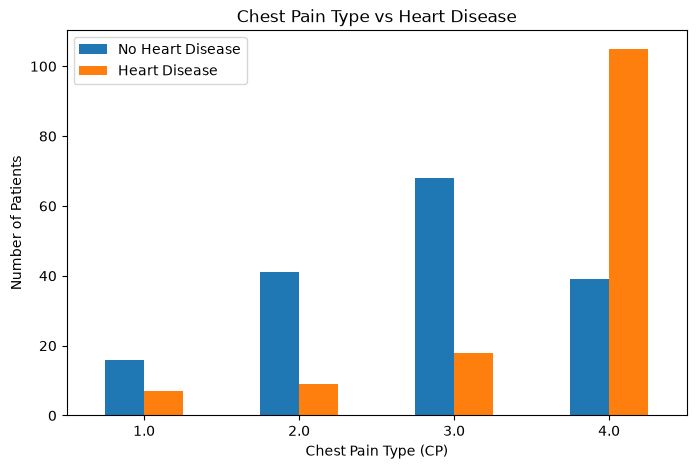

In [36]:
import matplotlib.pyplot as plt

pd.crosstab(df['cp'], df['target_binary']).plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (CP)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.show()

Heart disease percentage by chest pain type:
target_binary          0          1
cp                                 
1.0            69.565217  30.434783
2.0            82.000000  18.000000
3.0            79.069767  20.930233
4.0            27.083333  72.916667
Minimum resting blood pressure: 94.0
Maximum resting blood pressure: 200.0
Mean resting blood pressure: 131.68976897689768
Median resting blood pressure: 130.0


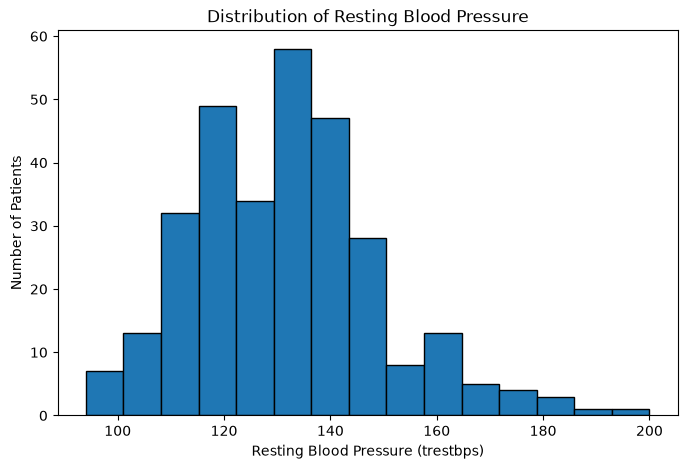

In [39]:
cp_percentage = pd.crosstab(
    df['cp'],
    df['target_binary'],
    normalize='index'
) * 100

print("Heart disease percentage by chest pain type:")
print(cp_percentage)

print("Minimum resting blood pressure:", df['trestbps'].min())
print("Maximum resting blood pressure:", df['trestbps'].max())
print("Mean resting blood pressure:", df['trestbps'].mean())
print("Median resting blood pressure:", df['trestbps'].median())

plt.figure(figsize=(8, 5))

plt.hist(df['trestbps'], bins=15, edgecolor='black')

plt.title('Distribution of Resting Blood Pressure')
plt.xlabel('Resting Blood Pressure (trestbps)')
plt.ylabel('Number of Patients')

plt.show()


In [40]:
print("Minimum cholesterol:", df['chol'].min())
print("Maximum cholesterol:", df['chol'].max())
print("Mean cholesterol:", df['chol'].mean())
print("Median cholesterol:", df['chol'].median())

Minimum cholesterol: 126.0
Maximum cholesterol: 564.0
Mean cholesterol: 246.69306930693068
Median cholesterol: 241.0


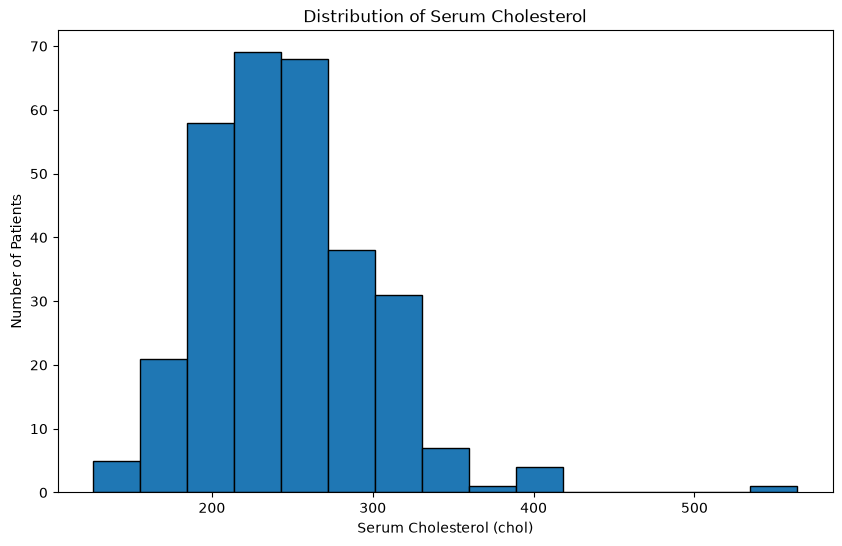

In [41]:
plt.figure(figsize=(10, 6))

plt.hist(df['chol'], bins=15, edgecolor='black')

plt.title('Distribution of Serum Cholesterol')
plt.xlabel('Serum Cholesterol (chol)')
plt.ylabel('Number of Patients')

plt.show()

Minimum cholesterol: 126.0
Maximum cholesterol: 564.0
Mean cholesterol: 246.69306930693068
Median cholesterol: 241.0


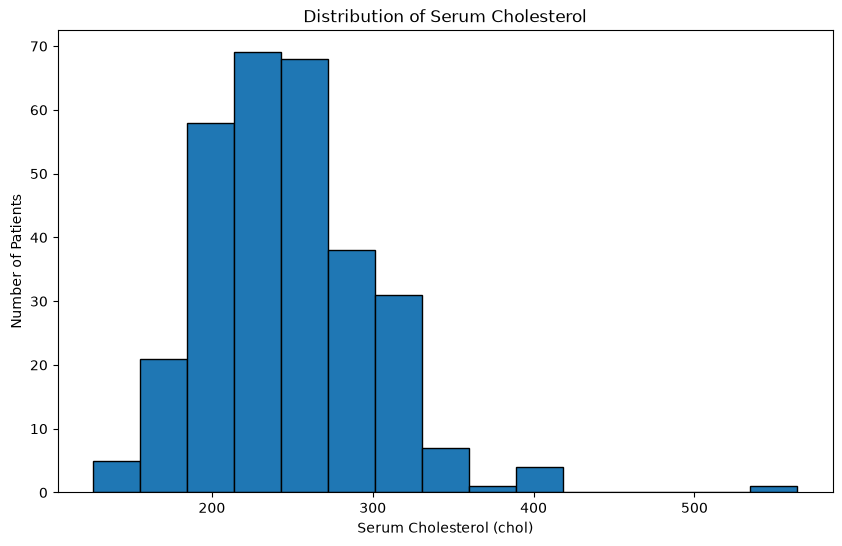

In [43]:
print("Minimum cholesterol:", df['chol'].min())
print("Maximum cholesterol:", df['chol'].max())
print("Mean cholesterol:", df['chol'].mean())
print("Median cholesterol:", df['chol'].median())

plt.figure(figsize=(10, 6))

plt.hist(df['chol'], bins=15, edgecolor='black')

plt.title('Distribution of Serum Cholesterol')
plt.xlabel('Serum Cholesterol (chol)')
plt.ylabel('Number of Patients')

plt.show()